In [23]:
#Automatically load changes to the imported files
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[*********************100%***********************]  1 of 1 completed


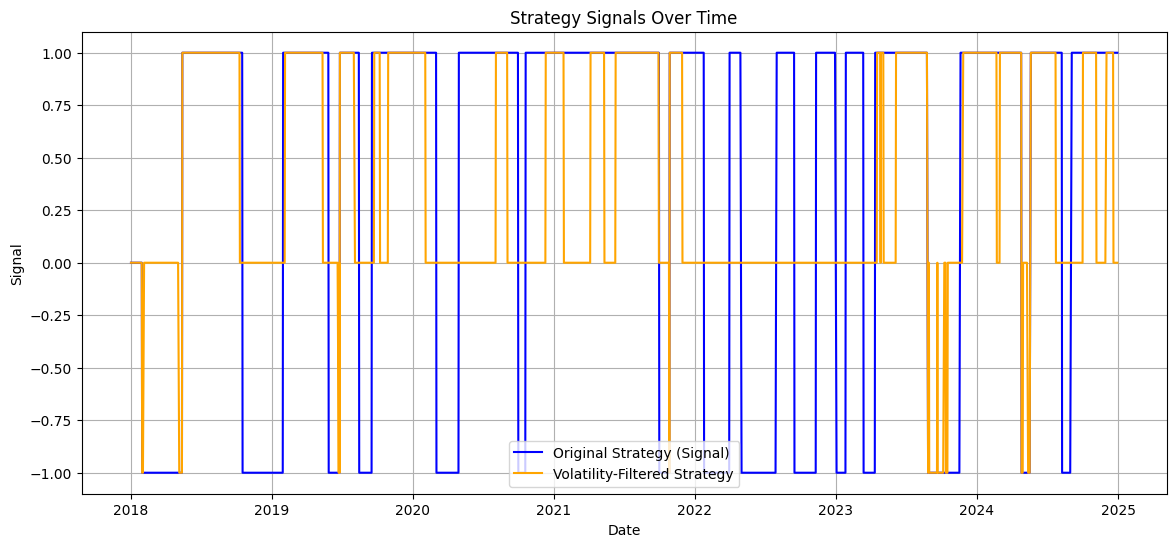

In [1]:
import sys
import os

# Add the project root to sys.path
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import get_data
from src.strategies import sma_crossover
from src.backtester import backtest
from src.performance import sharpe_ratio, max_drawdown

# Load data and base strategy
df = get_data("SPY")
df = sma_crossover(df)
df['Returns'] = df['Close'].pct_change()
df_bt = backtest(df)

# Add volatility filter
df['Volatility'] = df['Returns'].rolling(window=21).std()
df['FilteredSignal'] = df['Signal'].copy()
df.loc[df['Volatility'] > 0.008, 'FilteredSignal'] = 0

# Backtest with filtered signal
df_bt_filtered = backtest(df, signal_col='FilteredSignal')

# Plot strategy signals over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Signal'], label='Original Strategy (Signal)', color='blue')
plt.plot(df.index, df['FilteredSignal'], label='Volatility-Filtered Strategy', color='orange')
plt.title("Strategy Signals Over Time")
plt.xlabel("Date")
plt.ylabel("Signal")
plt.legend()
plt.grid(True)
plt.show()

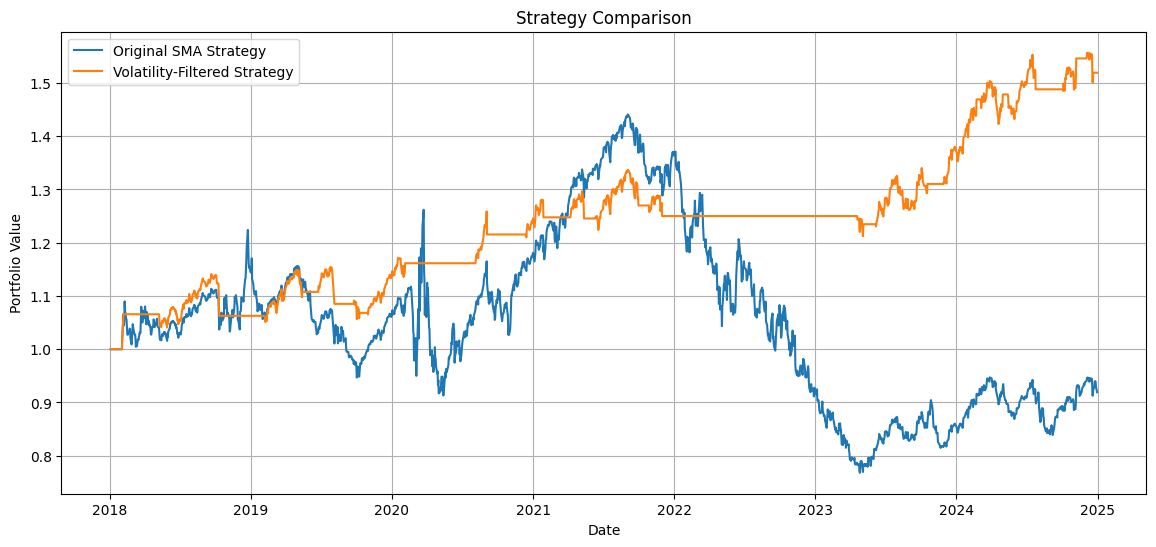

In [2]:
# Plot both Equity Curves
plt.figure(figsize=(14, 6))
plt.plot(df_bt['Equity'], label='Original SMA Strategy')
plt.plot(df_bt_filtered['Equity'], label='Volatility-Filtered Strategy')
plt.title("Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Performance metrics
print("Original Strategy:")
print(f"Sharpe Ratio: {sharpe_ratio(df_bt)}")
print(f"Max Drawdown: {max_drawdown(df_bt)}")

print("\nFiltered Strategy:")
print(f"Sharpe Ratio: {sharpe_ratio(df_bt_filtered)}")
print(f"Max Drawdown: {max_drawdown(df_bt_filtered)}")

Original Strategy:
Sharpe Ratio: 0.0353878296376586
Max Drawdown: -0.46690672580836273

Filtered Strategy:
Sharpe Ratio: 0.819067140165074
Max Drawdown: -0.0931059923809885
